##### Library Imports

In [1]:
%pip install paddleocr easyocr paddlepaddle -q
import easyocr
import matplotlib.pyplot as plt
import glob
import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image


from paddleocr import PaddleOCR


Note: you may need to restart the kernel to use updated packages.


# TESTS

## OUR AP IMAGES

In [2]:
path = "../ap_images/*.jpg"
image_paths = sorted(glob.glob(path))
image = [plt.imread(p) for p in image_paths if plt.imread(p) is not None]

print(f"Number of images loaded: {len(image)}")
display(image)

Number of images loaded: 19


[array([[[120, 121, 116],
         [120, 121, 116],
         [121, 122, 117],
         ...,
         [118, 119, 111],
         [123, 124, 116],
         [126, 127, 119]],
 
        [[120, 121, 116],
         [120, 121, 116],
         [121, 122, 117],
         ...,
         [120, 121, 113],
         [124, 125, 117],
         [124, 125, 117]],
 
        [[120, 121, 116],
         [121, 122, 117],
         [121, 122, 117],
         ...,
         [128, 129, 121],
         [128, 129, 121],
         [127, 128, 120]],
 
        ...,
 
        [[122, 122, 120],
         [122, 122, 120],
         [121, 121, 119],
         ...,
         [130, 131, 126],
         [129, 130, 125],
         [128, 129, 124]],
 
        [[122, 122, 120],
         [122, 122, 120],
         [121, 121, 119],
         ...,
         [129, 130, 125],
         [128, 129, 124],
         [128, 129, 124]],
 
        [[122, 122, 120],
         [122, 122, 120],
         [121, 121, 119],
         ...,
         [129, 130, 125],
  

## THE MODEL

In [3]:
reader = easyocr.Reader(['en'], gpu = True)

ocr = PaddleOCR(use_angle_cls=True, lang='en')

print("Models loaded successfully.")

/var/folders/dx/269nkrmx3wj8v33dc5znmyzh0000gn/T/ipykernel_23096/2796716272.py:3: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
/opt/anaconda3/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vieta/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vieta/.paddlex/official_mod

Models loaded successfully.


In [4]:
res_easy = []
i = 1
for img in image:
    result = reader.readtext(img)
    res_easy.append(result)
    print(f"Processed image number {i} with {len(result)} text detections.")
    i += 1
print("Easy OCR results obtained.")

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Processed image number 1 with 2 text detections.
Processed image number 2 with 2 text detections.
Processed image number 3 with 2 text detections.
Processed image number 4 with 2 text detections.
Processed image number 5 with 3 text detections.
Processed image number 6 with 1 text detections.
Processed image number 7 with 3 text detections.
Processed image number 8 with 2 text detections.
Processed image number 9 with 2 text detections.
Processed image number 10 with 0 text detections.
Processed image number 11 with 2 text detections.
Processed image number 12 with 2 text detections.
Processed image number 13 with 3 text detections.
Processed image number 14 with 1 text detections.
Processed image number 15 with 3 text detections.
Processed image number 16 with 3 text detections.
Processed image number 17 with 2 text detections.
Processed image number 18 with 3 text detections.
Processed image number 19 with 2 text detections.
Easy OCR results obtained.


In [5]:
len(res_easy)

19

In [6]:
def resize_image(img, max_side=1500):
    h, w = img.shape[:2]
    scale = max_side / max(h, w)

    if scale < 1:
        img_resized = cv2.resize(img, (int(w * scale), int(h * scale)))
        return img_resized, scale
    return img, 1.0

In [7]:
res_paddle = []
scaled_images = []
scales = []

for i, img in enumerate(image):
    img_resized, scale = resize_image(img, max_side=1500)

    result = ocr.ocr(img_resized)

    res_paddle.append(result)
    scaled_images.append(img_resized)
    scales.append(scale)

    print(f"Processed image {i} with scale {scale:.3f}")

/var/folders/dx/269nkrmx3wj8v33dc5znmyzh0000gn/T/ipykernel_23096/1665987258.py:8: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(img_resized)


Processed image 0 with scale 0.372
Processed image 1 with scale 0.372
Processed image 2 with scale 0.372
Processed image 3 with scale 0.372
Processed image 4 with scale 0.372
Processed image 5 with scale 0.372
Processed image 6 with scale 0.372
Processed image 7 with scale 0.372
Processed image 8 with scale 0.372
Processed image 9 with scale 0.372
Processed image 10 with scale 0.372
Processed image 11 with scale 0.372
Processed image 12 with scale 0.372
Processed image 13 with scale 0.372
Processed image 14 with scale 0.372
Processed image 15 with scale 0.372
Processed image 16 with scale 0.372
Processed image 17 with scale 0.372
Processed image 18 with scale 0.372


In [8]:
len(res_paddle)
display(res_paddle[0][0])


{'input_path': None,
 'page_index': None,
 'doc_preprocessor_res': {'input_path': None,
  'page_index': None,
  'input_img': array([[[120, ..., 116],
          ...,
          [124, ..., 117]],
  
         ...,
  
         [[122, ..., 120],
          ...,
          [128, ..., 124]]], shape=(1500, 1125, 3), dtype=uint8),
  'model_settings': {'use_doc_orientation_classify': True,
   'use_doc_unwarping': True},
  'angle': 0,
  'rot_img': array([[[120, ..., 116],
          ...,
          [124, ..., 117]],
  
         ...,
  
         [[122, ..., 120],
          ...,
          [128, ..., 124]]], shape=(1500, 1125, 3), dtype=uint8),
  'output_img': array([[[208, ..., 199],
          ...,
          [ 92, ...,  92]],
  
         ...,
  
         [[ 85, ...,  85],
          ...,
          [137, ..., 134]]], shape=(1500, 1125, 3), dtype=uint8)},
 'dt_polys': [array([[402, 579],
         ...,
         [382, 654]], shape=(4, 2), dtype=int16),
  array([[406, 677],
         ...,
         [397, 706]],

## RESULTS

[[np.float64(1218.410582355576), np.float64(1494.0066818809055)],
 [np.float64(1832.7012174037234), np.float64(1787.0696788977814)],
 [np.float64(1729.589417644424), np.float64(1986.9933181190945)],
 [np.float64(1114.2987825962766), np.float64(1692.9303211022186)]]

=============== Paddle OCR Results ===============


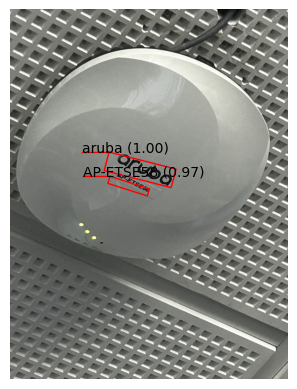

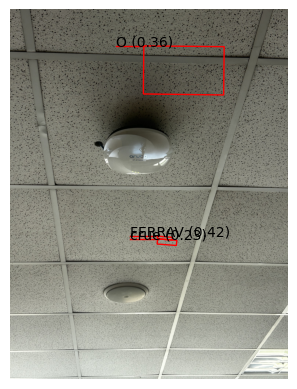

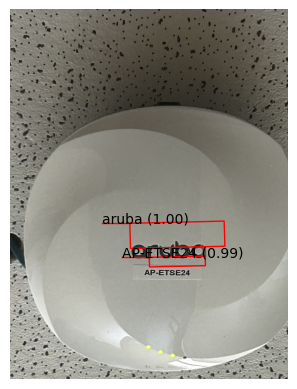

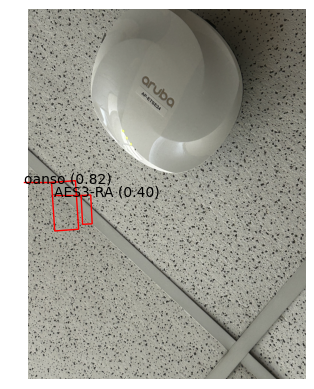

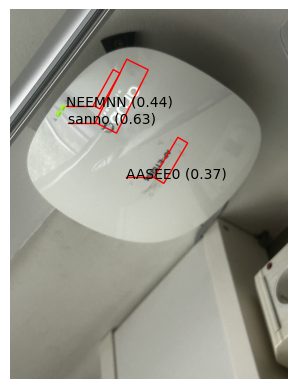

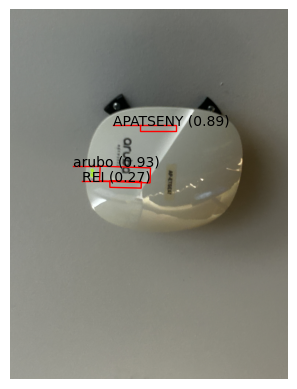

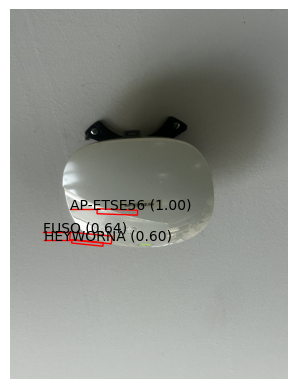

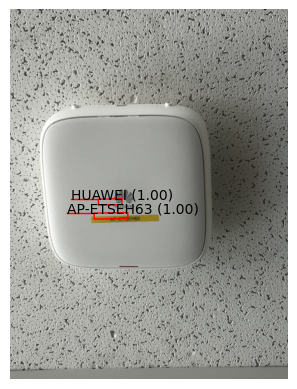

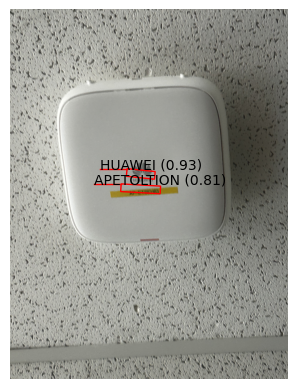

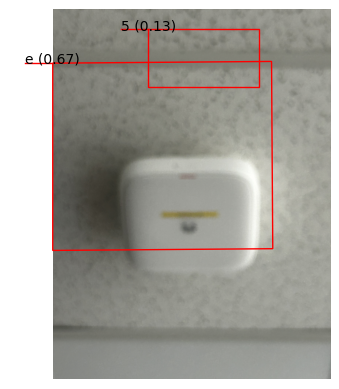

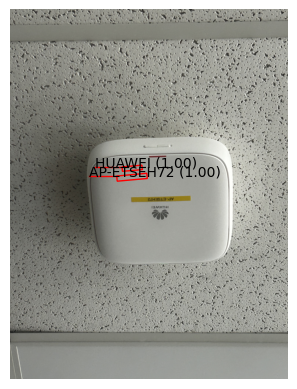

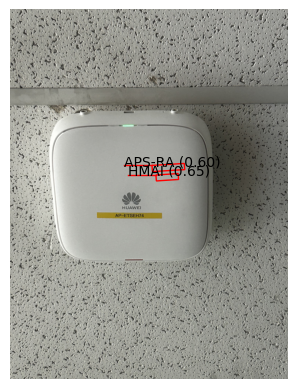

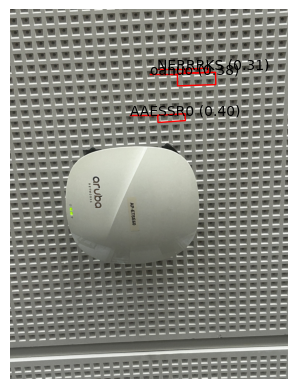

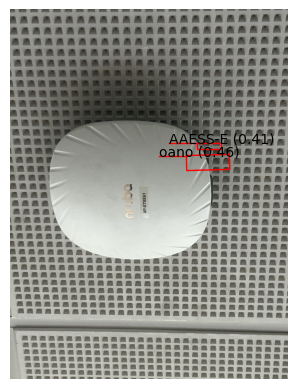

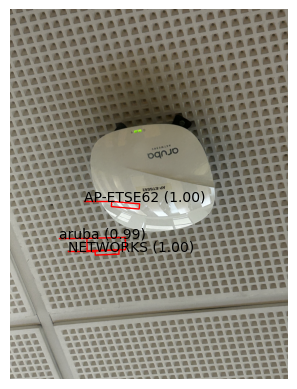

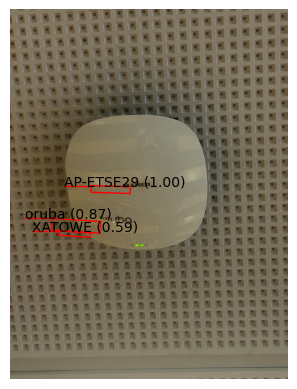

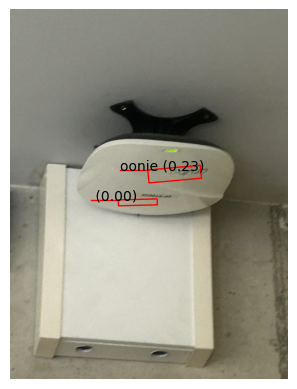

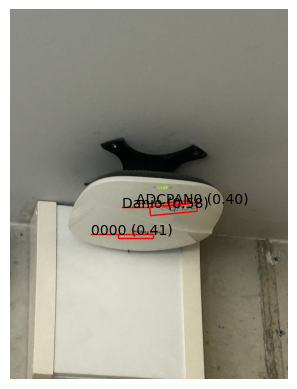

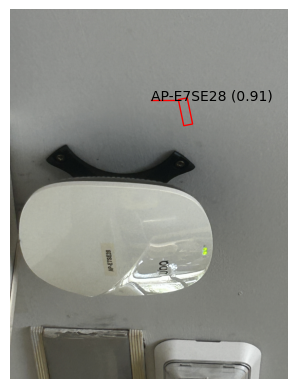

In [9]:
def get_coords(results):

    res = {}

    for element in range(len(results)):

        image_key = f"image_{element}"
        res[image_key] = []

        for identified in range(len(results[element])):

            detection = {
                "text": results[element][identified][1],
                "coords": results[element][identified][0],
                "conf": round(float(results[element][identified][2]), 4)
            }

            res[image_key].append(detection)

    return res

display(get_coords(res_easy)["image_0"][0]["coords"])

def normalize_results(results, backend="paddle", scales=None):
    res = {}

    for i, page in enumerate(results):
        image_key = f"image_{i}"
        res[image_key] = []

        if backend == "paddle":
            rec_texts = page[0]["rec_texts"]
            rec_scores = page[0]["rec_scores"]
            rec_polys  = page[0]["rec_polys"]

            scale = scales[i] if scales is not None else 1.0

            for text, score, poly in zip(rec_texts, rec_scores, rec_polys):

                poly = poly / scale   # <-- KEY FIX

                res[image_key].append({
                    "text": text,
                    "coords": poly.tolist() if hasattr(poly, "tolist") else poly,
                    "conf": float(score)
                })

    return res

def display_result(res, images):

    dic = res  # already normalized

    for i in range(len(images)):

        img = images[i]

        fig, ax = plt.subplots(1)
        ax.imshow(img)

        for detection in dic[f"image_{i}"]:

            polygon = patches.Polygon(
                detection["coords"],
                closed=True,
                edgecolor='red',
                fill=False,
                linewidth=1
            )
            ax.add_patch(polygon)

            x, y = detection["coords"][0]

            ax.plot([x, x-300], [y, y], color='red', linewidth=1)

            ax.text(
                x-300,
                y,
                f'{detection["text"]} ({detection["conf"]:.2f})',
                fontsize=10,
                color='black',
            )

        plt.axis("off")
        plt.show()



"""res_easy = normalize_results(res_easy, backend="easyocr")
print("=============== Easy OCR Results ===============")
display_result(res_easy, image)"""

res_paddle_norm = normalize_results(res_paddle, backend="paddle", scales=scales)
print("=============== Paddle OCR Results ===============")
display_result(res_paddle_norm, image)

# THE MODEL

Since paddle ocr performs better than easy ocr, and allows for rotated detection we will use that model. 

We will also implement a series of improvements such as forcing the outputs to be of the form
- AP-{faculty}{number}

In [10]:
import re
%pip install rapidfuzz -q
from rapidfuzz import process, fuzz


Note: you may need to restart the kernel to use updated packages.


In [11]:
faculties = ['DRET', 'CIEN', 'AMICS', 'LLET', 'ETSE', 'MED', 'CEDU', 'IGOP','EUREKA',
        'BIBCIE', 'BIBSOC', 'BIBHUM', 'CIVIC', 'CCOM', 'REC', 'MRC','DISP', 'B13',
        'SAF', 'AULAJ', 'HEMER','VET','GTIP','VH', 'ECON','QUIM','CREA','FTI','POL',
        'EDBLANC','ESCDOC','ECOSOC','IUEE','TERMICA','IBB','CBATEG','SI','IDIOMES',
        'TAULI','SAB','DEMOGRAF','DEIXALLERIA','MRB','EST','SPAU','ICTAIC','MRA']

# We do a mapping of common OCR mistakes
OCR_CONFUSIONS = {
    '0': ['O'],
    'O': ['0'],
    '1': ['I', 'L'],
    'I': ['1'],
    'L': ['1'],
    '5': ['S'],
    'S': ['5'],
    '3': ['E'],
    'E': ['3'],
    '7': ['T'],
    'T': ['7'],
    '8': ['B'],
    'B': ['8'],
    '6': ['G'],
    'G': ['6'],
    '2': ['Z'],
    'Z': ['2'],
    'A': ['4'],
    '4': ['A'],
    'P': ['F'],
    'F': ['P'],
}

FUZZY_THRESHOLD = 80   # minimum rapidfuzz score (0-100) to accept a faculty match
SUBSTITUTION_THRESHOLD = 75  # slightly lower threshold when using OCR substitutions

max_len = max(len(faculty) for faculty in faculties) + len("AP-") + 2

In [12]:
display(res_paddle[0][0]["rec_texts"])

['aruba', 'AP-ETSE58']

In [13]:
def normalize(text: str) -> str:
    """Uppercase and strip punctuation/spaces likely introduced by OCR."""
    text = text.upper()
    for ch in ' _.,;:|\\/-\t':
        text = text.replace(ch, '')
    return text
 
 
def ocr_variants(token: str):
    """
    Generate candidate strings by substituting one OCR-confused character at a time.
    Yields (variant, original_char, replacement_char) tuples.
    """
    for i, ch in enumerate(token):
        if ch in OCR_CONFUSIONS:
            for replacement in OCR_CONFUSIONS[ch]:
                yield token[:i] + replacement + token[i+1:]
 
 
def best_faculty_match(candidate: str, faculties: list[str]) -> str | None:
    """
    Try to match `candidate` to a known faculty code.
    First tries direct fuzzy match, then tries OCR-corrected variants.
    Returns the matched faculty string or None.
    """
    # Direct fuzzy match
    result = process.extractOne(candidate, faculties, scorer=fuzz.WRatio)
    if result and result[1] >= FUZZY_THRESHOLD:
        return result[0]
 
    # Try single-character OCR substitutions
    best_score = 0
    best_faculty = None
    for variant in ocr_variants(candidate):
        result = process.extractOne(variant, faculties, scorer=fuzz.WRatio)
        if result and result[1] > best_score:
            best_score = result[1]
            best_faculty = result[0]
 
    if best_score >= SUBSTITUTION_THRESHOLD:
        return best_faculty
 
    return None
 
 
# Regex: optionally match AP (with common OCR prefix errors) then a dash/separator,
# then capture the rest as the "payload" (faculty + number).
# We allow: A, 4, R, AP, 4P, HP, etc. as the "AP" prefix.
# The separator can be -, _, ., space, or just absent.
_PREFIX_RE = re.compile(
    r'^[A4R]?[PF]?[-_.\s]?([A-Z0-9]{2,})$'
)
 
# Match trailing digits (the access point number)
_TRAILING_DIGITS_RE = re.compile(r'^(.*?)(\d+)$')
 
 
def _strip_ap_prefix(text: str) -> str | None:
    """
    Given a normalised token like 'AP-DRET01', 'APDRET01', '4P-MED3', etc.,
    strip the AP prefix and separator and return the payload, or None if
    it doesn't look like an AP code at all.
    """
    # Must contain at least one letter that could be 'A' or 'P'
    if 'A' not in text and '4' not in text:
        return None
 
    m = _PREFIX_RE.match(text)
    if m:
        return m.group(1)
 
    # Fallback: if there's a '-' somewhere, take everything after the first one
    if '-' in text:
        payload = text.split('-', 1)[1]
        if len(payload) >= 2:
            return payload
 
    return None
 
 
def parse_ap_code(ocr_text: str) -> str | None:
    """
    Given a single OCR string, try to parse it into a canonical AP-{FACULTY}{number}.
    Returns the canonical string or None.
    """
    text = normalize(ocr_text)
 
    payload = _strip_ap_prefix(text)
    if payload is None:
        return None
 
    # Split payload into faculty candidate + trailing number
    m = _TRAILING_DIGITS_RE.match(payload)
    if m:
        fac_candidate = m.group(1)
        number = m.group(2)
    else:
        # No trailing digits found — still try to match the faculty
        fac_candidate = payload
        number = ''
 
    if not fac_candidate:
        return None
 
    faculty = best_faculty_match(fac_candidate, faculties)
    if faculty is None:
        return None
 
    # A number is expected; reject if missing
    if not number:
        return None
 
    return f'AP-{faculty}{number}'
 
 
def extract_best_ap_code(ocr_results) -> str | None:
    """
    Given a list of (box, (text, confidence)) tuples (PaddleOCR format),
    parse every recognised string and return the highest-confidence valid AP code.
 
    Accepts two input shapes:
      - PaddleOCR: [(box, (text, score)), ...]
      - Simple list of strings: ['AP-DRET01', ...]
    """
    candidates = []
 
    for item in ocr_results:
        # Support both PaddleOCR tuples and plain strings
        if isinstance(item, str):
            text, score = item, 1.0
        else:
            _box, (text, score) = item
 
        parsed = parse_ap_code(text)
        if parsed:
            candidates.append((parsed, score))
 
    if not candidates:
        return None
 
    # Return the parse from the highest-confidence OCR detection
    return max(candidates, key=lambda x: x[1])[0]
 
 
def extract_best_ap_code_from_texts(texts: list[str]) -> str | None:
    """
    Convenience wrapper: takes a flat list of OCR strings (e.g. rec_texts)
    and returns the best AP code found, or None.
    """
    candidates = [parse_ap_code(t) for t in texts]
    candidates = [c for c in candidates if c is not None]
    return candidates[0] if candidates else None 


results = []
for i in range(19):
    print(res_paddle[i][0]["rec_texts"])
    result = extract_best_ap_code_from_texts(res_paddle[i][0]["rec_texts"])
    results.append(result)

['aruba', 'AP-ETSE58']
['O', 'FERRAV', 'crue']
['aruba', 'AP-ETSE24']
['oanso', 'AES3-RA']
['NEEMNN', 'sanno', 'AASEE0']
['APATSENY', 'arubo', 'REI']
['AP-ETSE56', 'FUSO', 'HEYWORNA']
['HUAWEI', 'AP-ETSEH63']
['HUAWEI', 'APETOLTION']
['5', 'e']
['HUAWEI', 'AP-ETSEH72']
['APS-RA', 'HMAI']
['NERRRKS', 'oanuo', 'AAESSR0']
['AAESS-E', 'oano']
['AP-ETSE62', 'aruba', 'NETWORKS']
['AP-ETSE29', 'oruba', 'XATOWE']
['oonie', '']
['ADCPAN0', 'Danio', '0000']
['AP-E7SE28']


Now we have to:
- look for possible real AP of our dataset
- find their coords

In [14]:
from pathlib import Path
%pip install geopandas -q
import geopandas as gpd

geo_aps_84_path = Path(r"/Users/vieta/Documents/GitHub/uab-wifi-data-team-5/Data/aps_geolocalizados_wgs84.geojson")

geo_aps_84 = gpd.read_file(geo_aps_84_path)

display(geo_aps_84["USER_NOM_A"].head())

Note: you may need to restart the kernel to use updated packages.


0    AP-FTI02
1    AP-FTI05
2    AP-FTI06
3    AP-FTI07
4    AP-FTI08
Name: USER_NOM_A, dtype: object

In [15]:
# we want to find the coords of the aps we have identified in the photos
def ap_coords(result, df_geo_aps):
    if result in df_geo_aps["USER_NOM_A"].values:
        coords = df_geo_aps[df_geo_aps["USER_NOM_A"] == result]["geometry"].values[0]
        return coords
    else:
        return "No real AP code found in dataset"

for i in results:
    if i:
        coords = ap_coords(i, geo_aps_84) 
        print(f"Image {i}: AP Code: {i}, Coords: {coords}")


Image AP-ETSE58: AP Code: AP-ETSE58, Coords: POINT (2.112645187949246 41.50068167984375)
Image AP-ETSE24: AP Code: AP-ETSE24, Coords: POINT (2.112771281182885 41.50033374206681)
Image AP-ETSE56: AP Code: AP-ETSE56, Coords: POINT (2.112436594992018 41.500218091733935)
Image AP-ETSE63: AP Code: AP-ETSE63, Coords: POINT (2.112377924801944 41.500052810669914)
Image AP-ETSE72: AP Code: AP-ETSE72, Coords: POINT (2.112377924801944 41.500052810669914)
Image AP-ETSE62: AP Code: AP-ETSE62, Coords: POINT (2.112783124631551 41.500593955969805)
Image AP-ETSE29: AP Code: AP-ETSE29, Coords: POINT (2.112658735736119 41.50067377905185)
Image AP-ETSE28: AP Code: AP-ETSE28, Coords: POINT (2.112797692243322 41.500521246285665)


DO FINETUNING